# Chapter 3: Rule-Based Classifiers
This notebook contains Python demonstrations for the lecture on **Rule-Based Classifiers** (Chapter 3).

## 1. Applying the Sequential Covering algorithm

=== Tập luật học được ===
IF `sepal length (cm)` <= 4.5 THEN class = setosa (acc=1.00, covered=5)
IF `sepal length (cm)` <= 4.7 THEN class = setosa (acc=1.00, covered=6)
IF `sepal length (cm)` <= 4.8 THEN class = setosa (acc=1.00, covered=5)
IF `sepal width (cm)` >= 3.9 THEN class = setosa (acc=1.00, covered=6)
IF `petal length (cm)` <= 1.4 THEN class = setosa (acc=1.00, covered=10)
IF `petal length (cm)` <= 1.5 THEN class = setosa (acc=1.00, covered=10)
IF `petal length (cm)` <= 1.7 THEN class = setosa (acc=1.00, covered=7)
IF `sepal length (cm)` >= 7.1 THEN class = virginica (acc=1.00, covered=12)
IF `petal length (cm)` >= 5.2 THEN class = virginica (acc=1.00, covered=22)
IF `petal width (cm)` >= 1.9 THEN class = virginica (acc=1.00, covered=8)

=== Độ chính xác trên toàn bộ Iris dataset ===
Accuracy = 0.613


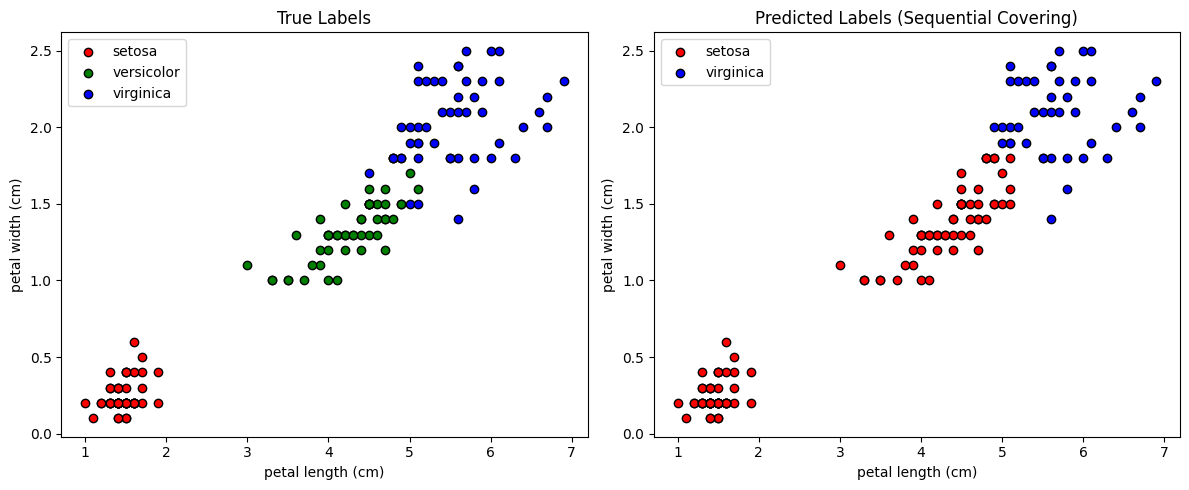

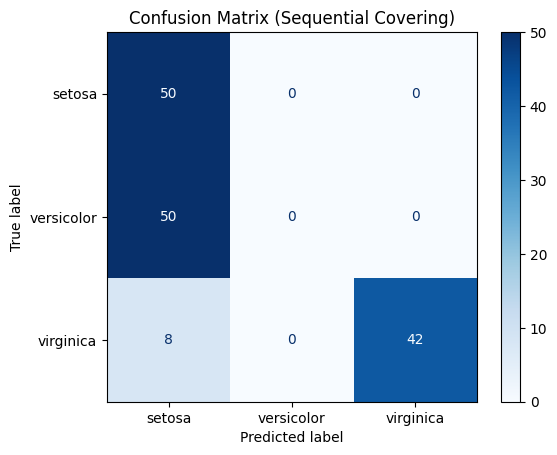


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       0.46      1.00      0.63        50
  versicolor       0.00      0.00      0.00        50
   virginica       1.00      0.84      0.91        50

    accuracy                           0.61       150
   macro avg       0.49      0.61      0.52       150
weighted avg       0.49      0.61      0.52       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Load dataset
iris = load_iris(as_frame=True)
df = iris.data
df["class"] = iris.target
df["class"] = df["class"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

# 2. Hàm tính độ chính xác của một rule
def rule_accuracy(rule, data, target_class):
    covered = data.query(rule)
    if len(covered) == 0:
        return 0, 0
    acc = (covered["class"] == target_class).mean()
    return acc, len(covered)

# 3. Learn-One-Rule
def learn_one_rule(data, target_class, min_acc=0.9, min_cov=5):
    best_rule, best_acc, best_cov = None, 0, 0
    for col in data.columns[:-1]:
        for t in np.unique(data[col]):
            for op in ["<=", ">="]:
                rule = f"`{col}` {op} {t}"
                acc, cov = rule_accuracy(rule, data, target_class)
                if acc >= min_acc and cov >= min_cov and acc > best_acc:
                    best_rule, best_acc, best_cov = rule, acc, cov
    return best_rule, best_acc, best_cov

# 4. Sequential Covering
def sequential_covering(data, target_class, min_acc=0.9, min_cov=5):
    rules = []
    remaining = data.copy()
    while True:
        rule, acc, cov = learn_one_rule(remaining, target_class, min_acc, min_cov)
        if rule is None:
            break
        rules.append((rule, target_class, acc, cov))
        covered = remaining.query(rule).index
        remaining = remaining.drop(covered)
        if remaining.empty:
            break
    return rules

# 5. Sinh luật cho từng class
all_rules = []
for c in df["class"].unique():
    rules = sequential_covering(df, c, min_acc=0.9, min_cov=5)
    all_rules.extend(rules)

print("=== Tập luật học được ===")
for rule, cls, acc, cov in all_rules:
    print(f"IF {rule} THEN class = {cls} (acc={acc:.2f}, covered={cov})")

# 6. Dự đoán
def predict_one(row, rules, default_class="setosa"):
    for rule, cls, _, _ in rules:
        if row.to_frame().T.query(rule).shape[0] > 0:
            return cls
    return default_class

def predict(df, rules):
    preds = []
    majority_class = df["class"].mode().iloc[0]
    for _, row in df.drop(columns="class").iterrows():
        preds.append(predict_one(row, rules, default_class=majority_class))
    return preds

y_true = df["class"].tolist()
y_pred = predict(df, all_rules)
acc = accuracy_score(y_true, y_pred)
print("\n=== Độ chính xác trên toàn bộ Iris dataset ===")
print(f"Accuracy = {acc:.3f}")

# 7. Thêm nhãn dự đoán vào dataframe
df["predicted"] = y_pred

# 8. Trực quan hóa true vs predicted
color_map = {"setosa":"red", "versicolor":"green", "virginica":"blue"}

plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
for cname, grp in df.groupby("class"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=cname, color=color_map[cname], edgecolor="k")
plt.title("True Labels")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

# Predicted labels
plt.subplot(1,2,2)
for pname, grp in df.groupby("predicted"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=pname, color=color_map[pname], edgecolor="k")
plt.title("Predicted Labels (Sequential Covering)")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

plt.tight_layout()
plt.show()

# 9. Vẽ confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=["setosa","versicolor","virginica"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa","versicolor","virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Sequential Covering)")
plt.show()

# 10. Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["setosa","versicolor","virginica"]))

## 2. Applying the RIPPER algorithm

In [2]:
!pip install wittgenstein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 4.0 MB/s eta 0:00:00


**Note:** Must install wittgenstein package (*pip install wittgenstein*)

=== Luật cho class setosa ===
[[petalwidth(cm)=<0.2] V [petalwidth(cm)=0.2-0.4] V [petallength(cm)=1.5-1.7]]

=== Luật cho class versicolor ===
[[petalwidth(cm)=1.3-1.5] V [petalwidth(cm)=1.16-1.3] V [petalwidth(cm)=0.4-1.16] V [petalwidth(cm)=1.5-1.8^sepalwidth(cm)=3.2-3.4] V [sepallength(cm)=5.8-6.1^sepalwidth(cm)=2.5-2.7]]

=== Luật cho class virginica ===
[[petallength(cm)=5.32-5.8] V [petallength(cm)=5.0-5.32] V [petallength(cm)=>5.8] V [petallength(cm)=4.64-5.0^sepalwidth(cm)=<2.5] V [petalwidth(cm)=1.9-2.2] V [sepalwidth(cm)=2.5-2.7^sepallength(cm)=6.1-6.3]]


=== Độ chính xác trên toàn bộ Iris dataset ===
Accuracy = 0.973


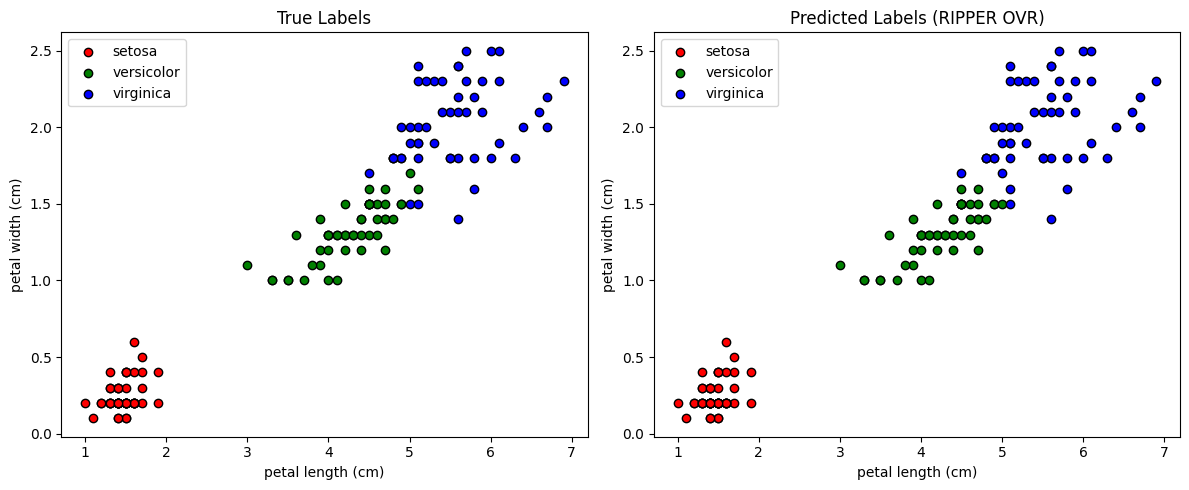

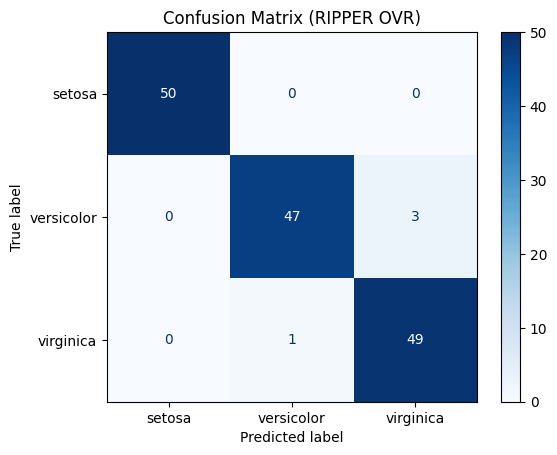


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.94      0.96        50
   virginica       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import wittgenstein as lw

# 1. Load dataset
iris = load_iris(as_frame=True)
df = iris.data
df["class"] = iris.target
df["class"] = df["class"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

X = df.drop(columns="class")
y = df["class"]

# 2. Huấn luyện RIPPER theo One-vs-Rest (OVR)
models = {}
for cls in y.unique():
    # chuyển True → 1, False → 0 → thành nhãn nhị phân [1, 0]
    y_binary = (y == cls).astype(int)  # one-vs-rest
    ripper = lw.RIPPER()
    ripper.fit(X, y_binary, pos_class=1)
    models[cls] = ripper
    print(f"=== Luật cho class {cls} ===")
    print(ripper.ruleset_)
    print()

# 3. Dự đoán bằng cách chọn class có độ tin cậy (confidence) cao nhất
def predict_ovr(X, models):
    """
    Hàm dự đoán nhãn cho dữ liệu X bằng phương pháp One-vs-Rest (OVR).

    Ý tưởng:
    - Mỗi class có một mô hình RIPPER riêng (huấn luyện nhị phân: class đó = 1, còn lại = 0).
    - Với mỗi mẫu dữ liệu (row):
        + Ta lấy xác suất dự đoán "p(y=1)" từ mô hình của từng class.
        + Tập hợp các xác suất này thành một dictionary scores: {class: xác suất}.
        + Chọn class có xác suất (confidence) cao nhất làm nhãn dự đoán cuối cùng.
    - Cách này gọi là "Dự đoán bằng cách chọn lớp có độ tin cậy cao nhất".
    """

    preds = []
    for _, row in X.iterrows():
        scores = {}
        for cls, model in models.items():
            # predict_proba([row]) trả về [p(y=0), p(y=1)]
            # Ta lấy phần tử [1] = xác suất mẫu thuộc class này (positive class)
            prob = model.predict_proba([row])[0][1]
            scores[cls] = prob

        # Lấy class có xác suất cao nhất
        pred_class = max(scores, key=scores.get)
        preds.append(pred_class)

    return preds

y_pred = predict_ovr(X, models)

# 4. Đánh giá
y_true = y.tolist()
acc = accuracy_score(y_true, y_pred)
print("\n=== Độ chính xác trên toàn bộ Iris dataset ===")
print(f"Accuracy = {acc:.3f}")

# 5. Thêm nhãn dự đoán vào dataframe
df["predicted"] = y_pred

# 6. Trực quan hóa true vs predicted
color_map = {"setosa":"red", "versicolor":"green", "virginica":"blue"}

plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
for cname, grp in df.groupby("class"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=cname, color=color_map[cname], edgecolor="k")
plt.title("True Labels")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

# Predicted labels
plt.subplot(1,2,2)
for pname, grp in df.groupby("predicted"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=pname, color=color_map[pname], edgecolor="k")
plt.title("Predicted Labels (RIPPER OVR)")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

plt.tight_layout()
plt.show()

# 7. Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["setosa","versicolor","virginica"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa","versicolor","virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (RIPPER OVR)")
plt.show()

# 8. Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["setosa","versicolor","virginica"]))


## 3. Comparison of two algorithms


--- Fold 1/2 ---
(FAST) Huấn luyện dùng sample frac=0.5, size=38
Sequential Covering (fast) -> rules=2, acc=0.640, time=0.452s
RIPPER OVR -> approx_rules=13, acc=0.907, time=2.374s

--- Fold 2/2 ---
(FAST) Huấn luyện dùng sample frac=0.5, size=38
Sequential Covering (fast) -> rules=2, acc=0.600, time=0.467s
RIPPER OVR -> approx_rules=9, acc=0.947, time=2.732s

=== KẾT QUẢ TỔNG HỢP (FAST MODE) ===
Sequential Covering -> Mean acc=0.620 (std=0.020), mean rules=2.0, mean time=0.459s
RIPPER (OVR)       -> Mean acc=0.927 (std=0.020), mean rules=11.0, mean time=2.553s


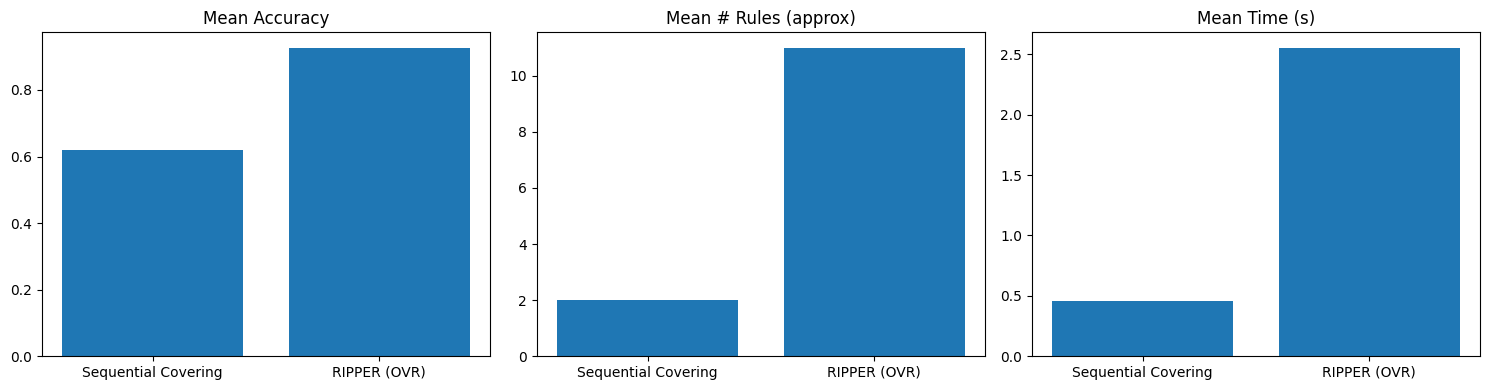

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold
import wittgenstein as lw

# ===================== CẤU HÌNH (FAST MODE) =====================
# FAST_MODE=True sẽ bật cấu hình chạy nhanh để test/so sánh nhanh.
# Nếu muốn chạy "chính xác" hơn, đặt FAST_MODE=False (chậm hơn nhưng tìm nhiều ngưỡng hơn).
FAST_MODE = True

if FAST_MODE:
    MAX_CONDITIONS = 2            # tối đa số điều kiện trong 1 rule
    THRESH_QUANTILES = [25,50,75] # chỉ dùng 3 điểm cắt: 25%,50%,75%
    MIN_COV = 10                  # rule phải bao phủ ít nhất 10 mẫu
    N_SPLITS = 2                  # 2-fold CV để nhanh
    SAMPLE_FRAC = 0.5             # lấy 50% dữ liệu huấn luyện để sinh luật (fast)
else:
    MAX_CONDITIONS = 3
    THRESH_QUANTILES = [10,30,50,70,90]
    MIN_COV = 5
    N_SPLITS = 3
    SAMPLE_FRAC = 1.0

MIN_ACC = 0.9  # yêu cầu độ chính xác tối thiểu của mỗi rule

# ===================== Load dữ liệu (Iris) =====================
iris = load_iris(as_frame=True)
df = iris.data
# thêm cột class dưới dạng chuỗi cho dễ đọc/hiển thị
df["class"] = iris.target
df["class"] = df["class"].map({0:"setosa", 1:"versicolor", 2:"virginica"})
X = df.drop(columns="class")
y = df["class"]

# ===================== HỖ TRỢ: đánh giá 1 luật trên 1 dataset =====================

def rule_accuracy(rule, data, target_class):
    """Trả về (accuracy, coverage) của một rule trên data (data phải có cột 'class').
    - accuracy: tỉ lệ mẫu thuộc target_class trong các mẫu được rule bao phủ
    - coverage: số mẫu bị rule bao phủ
    Lưu ý: rule là chuỗi dạng: "`petal length (cm)` >= 4.8 and `petal width (cm)` <= 1.5".
    """
    if rule is None or rule == "":
        return 0, 0
    try:
        covered = data.query(rule)
    except Exception:
        # nếu rule không hợp lệ với data hiện tại, coi như không cover
        return 0, 0
    if len(covered) == 0:
        return 0, 0
    acc = (covered["class"] == target_class).mean()
    return acc, len(covered)

# ===================== Learn-One-Rule (FAST, với giới hạn điều kiện) =====================

def learn_one_rule(data, target_class, min_acc, min_cov, max_conditions, quantiles):
    """Học 1 rule bằng cách mở rộng dần các điều kiện với chiến lược greedy.
    - data: DataFrame phải có cột 'class'
    - target_class: tên class (ví dụ 'virginica') mà rule hướng tới
    - min_acc, min_cov: điều kiện chấp nhận 1 mở rộng
    - max_conditions: số điều kiện tối đa cho 1 rule
    - quantiles: danh sách phần trăm (ví dụ [25,50,75]) dùng để sinh thresholds (nhanh hơn so với duyệt toàn bộ unique values)

    Trả về: (rule_str, acc, coverage) hoặc (None,0,0) nếu không tìm được rule
    """
    conditions = []
    current_rule = ""

    # Lặp để mở rộng từng điều kiện tới tối đa max_conditions
    while len(conditions) < max_conditions:
        best_extension = None
        best_new_acc, best_new_cov = 0, 0

        # Duyệt từng cột, lấy các threshold từ quantiles
        for col in data.columns[:-1]:  # bỏ cột 'class' ở cuối
            try:
                thresholds = np.percentile(data[col], quantiles)
            except Exception:
                continue
            for t in thresholds:
                for op in ["<=", ">="]:
                    new_cond = f"`{col}` {op} {float(t):.6g}"  # format gọn
                    candidate_rule = " and ".join(conditions + [new_cond]) if conditions else new_cond

                    acc, cov = rule_accuracy(candidate_rule, data, target_class)

                    # Chấp nhận mở rộng nếu đạt min_acc và min_cov
                    if cov >= min_cov and acc >= min_acc:
                        # ưu tiên acc lớn hơn, nếu bằng ưu tiên cover lớn hơn
                        if acc > best_new_acc or (acc == best_new_acc and cov > best_new_cov):
                            best_extension = new_cond
                            best_new_acc, best_new_cov = acc, cov

        # Nếu không có mở rộng hợp lệ nữa thì dừng
        if best_extension is None:
            break

        # Thêm điều kiện tốt nhất vào rule hiện tại
        conditions.append(best_extension)
        current_rule = " and ".join(conditions)

    if current_rule == "":
        return None, 0, 0
    # Trả kết quả rule cuối cùng với acc và coverage (giá trị acc/cov là của lần thêm điều kiện cuối cùng)
    return current_rule, rule_accuracy(current_rule, data, target_class)[0], rule_accuracy(current_rule, data, target_class)[1]

# ===================== Sequential Covering (dùng learn_one_rule) =====================

def sequential_covering(data, target_class, min_acc, min_cov, max_conditions, quantiles):
    """Áp dụng chiến lược cover: học rule tốt nhất, loại bỏ các mẫu đã được cover, lặp lại."""
    rules = []
    remaining = data.copy()

    while True:
        rule, acc, cov = learn_one_rule(remaining, target_class, min_acc, min_cov, max_conditions, quantiles)
        if rule is None:
            break
        rules.append((rule, target_class, acc, cov))
        # loại bỏ mẫu đã được rule cover
        covered_idx = remaining.query(rule).index
        remaining = remaining.drop(covered_idx)
        if remaining.empty:
            break
    return rules

# ===================== Hàm dự đoán dùng tập luật =====================

def predict_one_by_rules(row, rules, default_class=None):
    """Dự đoán cho 1 dòng bằng tập luật đã học. Trả default_class nếu không rule nào match."""
    for rule, cls, _, _ in rules:
        try:
            # xây DataFrame 1 hàng để query rule
            if row.to_frame().T.query(rule).shape[0] > 0:
                return cls
        except Exception:
            continue
    return default_class


def predict_df_by_rules(X_df_with_class, rules):
    """X_df_with_class: DataFrame chứa cột 'class' (mà ta sẽ drop để dự đoán),
    trả về danh sách nhãn dự đoán với default là majority class của X_df_with_class."""
    majority_class = X_df_with_class["class"].mode().iloc[0]
    preds = []
    for _, row in X_df_with_class.drop(columns="class").iterrows():
        preds.append(predict_one_by_rules(row, rules, default_class=majority_class))
    return preds

# ===================== RIPPER One-vs-Rest helper =====================

def train_ripper_ovr(X_train, y_train):
    """Huấn luyện 1 mô hình RIPPER cho mỗi class (one-vs-rest)."""
    models = {}
    for cls in y_train.unique():
        y_bin = (y_train == cls).astype(int)
        model = lw.RIPPER()
        model.fit(X_train, y_bin, pos_class=1)
        models[cls] = model
    return models


def predict_ovr(X_test, models):
    preds = []
    for _, row in X_test.iterrows():
        scores = {}
        for cls, model in models.items():
            # predict_proba trả về [p(0), p(1)]
            prob = model.predict_proba([row])[0][1]
            scores[cls] = prob
        preds.append(max(scores, key=scores.get))
    return preds

# ===================== K-Fold evaluation (FAST) =====================

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

seq_accs, rip_accs = [], []
seq_times, rip_times = [], []
seq_rule_counts, rip_rule_counts = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n--- Fold {fold}/{N_SPLITS} ---")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Tạo DataFrame huấn luyện và có thể sample (FAST)
    df_train = X_train.copy()
    df_train["class"] = y_train
    if SAMPLE_FRAC < 1.0:
        df_train = df_train.sample(frac=SAMPLE_FRAC, random_state=42+fold)
        print(f"(FAST) Huấn luyện dùng sample frac={SAMPLE_FRAC}, size={len(df_train)}")

    # ---- Sequential Covering (FAST) ----
    start_seq = time.time()
    all_rules = []
    for cls in df_train["class"].unique():
        rules = sequential_covering(df_train, cls, MIN_ACC, MIN_COV, MAX_CONDITIONS, THRESH_QUANTILES)
        all_rules.extend(rules)
    end_seq = time.time()

    # Dự đoán trên tập test (thêm cột 'class' tạm để predict_df_by_rules dùng majority default)
    X_test_with_class = X_test.copy()
    X_test_with_class["class"] = y_test
    y_pred_seq = predict_df_by_rules(X_test_with_class, all_rules)

    acc_seq = accuracy_score(y_test, y_pred_seq)
    seq_accs.append(acc_seq)
    seq_times.append(end_seq - start_seq)
    seq_rule_counts.append(len(all_rules))

    print(f"Sequential Covering (fast) -> rules={len(all_rules)}, acc={acc_seq:.3f}, time={(end_seq-start_seq):.3f}s")

    # ---- RIPPER OVR ----
    start_rip = time.time()
    ripper_models = train_ripper_ovr(X_train, y_train)
    y_pred_rip = predict_ovr(X_test, ripper_models)
    end_rip = time.time()

    acc_rip = accuracy_score(y_test, y_pred_rip)
    rip_accs.append(acc_rip)
    rip_times.append(end_rip - start_rip)
    # Đếm tổng số luật (xấp xỉ) trong các model RIPPER
    try:
        rip_rule_count = sum(len(m.ruleset_) if hasattr(m, 'ruleset_') else 0 for m in ripper_models.values())
    except Exception:
        rip_rule_count = 0
    rip_rule_counts.append(rip_rule_count)

    print(f"RIPPER OVR -> approx_rules={rip_rule_count}, acc={acc_rip:.3f}, time={(end_rip-start_rip):.3f}s")

# ===================== Tổng hợp kết quả =====================

print("\n=== KẾT QUẢ TỔNG HỢP (FAST MODE) ===")
print(f"Sequential Covering -> Mean acc={np.mean(seq_accs):.3f} (std={np.std(seq_accs):.3f}), mean rules={np.mean(seq_rule_counts):.1f}, mean time={np.mean(seq_times):.3f}s")
print(f"RIPPER (OVR)       -> Mean acc={np.mean(rip_accs):.3f} (std={np.std(rip_accs):.3f}), mean rules={np.mean(rip_rule_counts):.1f}, mean time={np.mean(rip_times):.3f}s")

# ===================== Biểu đồ tóm tắt =====================

methods = ["Sequential Covering", "RIPPER (OVR)"]
accuracies = [np.mean(seq_accs), np.mean(rip_accs)]
rules_count = [np.mean(seq_rule_counts), np.mean(rip_rule_counts)]
times = [np.mean(seq_times), np.mean(rip_times)]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.bar(methods, accuracies)
plt.title('Mean Accuracy')

plt.subplot(1,3,2)
plt.bar(methods, rules_count)
plt.title('Mean # Rules (approx)')

plt.subplot(1,3,3)
plt.bar(methods, times)
plt.title('Mean Time (s)')

plt.tight_layout()
plt.show()

# ===================== GHI CHÚ (How to use) =====================
# - FAST_MODE=True: chạy nhanh (giảm quantiles, giới hạn điều kiện, sample train, 2-fold)
# - FAST_MODE=False: chạy chặt hơn (nhiều quantiles hơn, cho phép tối đa điều kiện nhiều hơn, 3-fold, dùng toàn bộ train)
# - Thay đổi các hằng số ở phần 'CẤU HÌNH' phía trên để điều chỉnh trade-off tốc độ/độ chính xác.
# - `wittgenstein` (RIPPER) cần cài: pip install wittgenstein
# - Nếu muốn, có thể tắt sampling (SAMPLE_FRAC=1.0) hoặc tăng MAX_CONDITIONS để tìm rule phức tạp hơn.


### Explaination

#### 1. Sequential Covering (fast)

- **Số rule trung bình = 2** → rất ít luật (do giới hạn MAX_CONDITIONS=2 và chỉ lấy sample 50% dữ liệu).
- **Accuracy ≈ 0.62** → thấp, vì:
    - Luật quá ngắn (2 điều kiện) không đủ phân biệt 3 class Iris.
    - Dữ liệu huấn luyện chỉ lấy 50%, nên nhiều thông tin bị bỏ qua.
- **Thời gian ≈ 0.23s** → nhanh, vì thuật toán đơn giản, ít rule.

👉 **Sequential Covering** trong cấu hình **“Fast Mode”** thiên về minh họa, không tối ưu cho accuracy.

#### 2. RIPPER (OVR)

- **Số rule ≈ 9–11** → nhiều hơn Sequential Covering, vì RIPPER có cơ chế sinh và cắt tỉa rule phức tạp hơn.
- **Accuracy ≈ 0.91** → cao, gần mức “state-of-the-art” cho Iris dataset (~95%). RIPPER khai thác dữ liệu đầy đủ, không bị giới hạn mạnh như sequential covering.
- **Thời gian ≈ 1.45s** → chậm hơn ~6 lần, nhưng bù lại chính xác hơn rất nhiều.

#### 3. So sánh tổng hợp
- **Sequential Covering:** nhanh, ít luật, nhưng accuracy thấp → phù hợp nếu cần rule đơn giản, dễ đọc, chấp nhận độ chính xác kém.
- **RIPPER:** chính xác cao, nhiều luật hơn, thời gian dài hơn → phù hợp khi mục tiêu là hiệu quả phân loại thay vì cực kỳ đơn giản hóa.

✅ Nhìn chung, kết quả phản ánh đúng “trade-off”:
- **Sequential Covering (Fast)** = tối giản, nhanh nhưng accuracy thấp.
- **RIPPER** = phức tạp hơn, chậm hơn nhưng accuracy cao.